# Survival Analysis Beyond Medicine

Survival analysis is often associated with clinical trials, but the same mathematical framework applies
to any domain where you are modeling **time until an event** in the presence of **incomplete observations (censoring)**.

This notebook demonstrates `TorchSurv` across five real-world domains:

| # | Domain | "Event" | "Time" | Model |
|---|---|---|---|---|
| 1 | **Customer Churn** (Telecom) | Subscription cancellation | Duration as subscriber | Cox |
| 2 | **Employee Attrition** (HR) | Employee resignation | Tenure | Weibull AFT |
| 3 | **Equipment Failure** (Maintenance) | Machine breakdown | Operating hours | Cox |
| 4 | **Loan Default** (Finance) | Default event | Months since origination | Weibull AFT |
| 5 | **Extreme Weather Events** (Meteorology) | Threshold exceedance | Days between events | Cox |

Each section:

- Generates **synthetic data** with realistic distributions (fixed seeds for reproducibility)
- Points to a **real public dataset** you can use as a drop-in replacement
- Trains either a **Cox** or **Weibull AFT** model using a simple MLP backbone
- Evaluates with **C-index** and **time-dependent AUC**

A final section compares performance across all domains.

In [1]:
# Optional: install dependencies if running in a fresh environment
# %pip install torchsurv matplotlib scikit-learn

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

from torchsurv.loss import cox, weibull
from torchsurv.metrics.auc import Auc
from torchsurv.metrics.cindex import ConcordanceIndex

torch.manual_seed(42)
np.random.seed(42)

## Shared Utilities

The helper code below is used by all domain sections. It defines:

- A generic **MLP** backbone
- A generic **training loop**
- A **SurvivalDataset** wrapper
- A **plot_losses** utility

In [4]:
class MLP(nn.Module):
    """Simple multi-layer perceptron for survival modeling.

    Args:
        in_features: Number of input features.
        out_features: 1 for Cox (log relative hazard), 2 for Weibull (log scale parameter, log shape parameter).
        hidden: Sequence of hidden layer widths.
    """

    def __init__(self, in_features: int, out_features: int = 1, hidden: tuple = (64, 32)):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, out_features))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class SurvivalDataset(Dataset):
    """Wraps feature matrix X with (event, time) survival targets."""

    def __init__(self, X: np.ndarray, event: np.ndarray, time: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.event = torch.tensor(event, dtype=torch.bool)
        self.time = torch.tensor(time, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], (self.event[idx], self.time[idx])


def make_loaders(X, event, time, test_size=0.2, val_size=0.1, batch_size=64):
    """Split into train/val/test and return DataLoaders."""
    X_tv, X_test, e_tv, e_test, t_tv, t_test = train_test_split(X, event, time, test_size=test_size, random_state=42)
    X_train, X_val, e_train, e_val, t_train, t_val = train_test_split(
        X_tv, e_tv, t_tv, test_size=val_size / (1 - test_size), random_state=42
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    loader_train = DataLoader(SurvivalDataset(X_train, e_train, t_train), batch_size=batch_size, shuffle=True)
    loader_val = DataLoader(SurvivalDataset(X_val, e_val, t_val), batch_size=batch_size)
    loader_test = DataLoader(SurvivalDataset(X_test, e_test, t_test), batch_size=len(X_test))
    return loader_train, loader_val, loader_test


def train(model, loader_train, loader_val, loss_fn, lr=1e-3, epochs=60):
    """Generic training loop. Returns (train_losses, val_losses)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []

    for _ in range(epochs):
        model.train()
        epoch_loss = torch.tensor(0.0)
        for X_batch, (event_batch, time_batch) in loader_train:
            optimizer.zero_grad()
            out = model(X_batch)
            loss = loss_fn(out, event_batch, time_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.detach()
        train_losses.append(epoch_loss / len(loader_train))

        model.eval()
        with torch.no_grad():
            val_loss = torch.tensor(0.0)
            for X_batch, (event_batch, time_batch) in loader_val:
                out = model(X_batch)
                val_loss += loss_fn(out, event_batch, time_batch)
            val_losses.append(val_loss / len(loader_val))

    return train_losses, val_losses


def plot_losses(train_losses, val_losses, title: str = "") -> None:
    train_norm = torch.stack(train_losses) / train_losses[0]
    val_norm = torch.stack(val_losses) / val_losses[0]
    plt.figure(figsize=(6, 3))
    plt.plot(train_norm.numpy(), label="train")
    plt.plot(val_norm.numpy(), label="validation")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Normalized loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_cox(model, loader_test, domain_name: str) -> dict:
    """Evaluate a Cox model. Returns dict of metrics."""
    model.eval()
    with torch.no_grad():
        X_test, (event_test, time_test) = next(iter(loader_test))
        log_hz = model(X_test)

    # Survival function estimate via Breslow
    # C-index
    ci = ConcordanceIndex()
    c = ci(log_hz, event_test, time_test)

    # AUC at median time
    median_t = time_test.median()
    auc_metric = Auc()
    auc_val = auc_metric(estimate=log_hz, event=event_test, time=time_test, new_time=median_t)

    # Brier Score
    # Estimate survival probabilities using Cox baseline
    # We use the proportional hazards structure: S(t|x) = S0(t)^exp(log_hz)
    # Baseline survival from Kaplan-Meier on training (approximation)
    print("=" * 50)
    print(f" {domain_name} — Cox Model Results")
    print(f"{'=' * 50}")
    print(f"  C-index         : {c.item():.4f}")
    print(f"  95% CI          : {ci.confidence_interval()}")
    print(f"  AUC (median t)  : {auc_val.item():.4f}")
    print(f"{'=' * 50}")
    return {"domain": domain_name, "model": "Cox", "cindex": c.item(), "auc": auc_val.item()}


def evaluate_weibull(model, loader_test, domain_name: str) -> dict:
    """Evaluate a Weibull AFT model. Returns dict of metrics."""
    model.eval()
    with torch.no_grad():
        X_test, (event_test, time_test) = next(iter(loader_test))
        params = model(X_test)  # shape (N, 2): [log_scale, log_shape]
        log_scale = params[:, 0:1]

    # C-index (use negative log_scale as risk score — higher scale = longer survival)
    ci = ConcordanceIndex()
    c = ci(-log_scale, event_test, time_test)

    # AUC at median time
    median_t = time_test.median()
    auc_metric = Auc()
    auc_val = auc_metric(estimate=-log_scale, event=event_test, time=time_test, new_time=median_t)

    print("=" * 50)
    print(f" {domain_name} — Weibull AFT Model Results")
    print(f"{'=' * 50}")
    print(f"  C-index         : {c.item():.4f}")
    print(f"  95% CI          : {ci.confidence_interval()}")
    print(f"  AUC (median t)  : {auc_val.item():.4f}")
    print(f"{'=' * 50}")
    return {"domain": domain_name, "model": "Weibull AFT", "cindex": c.item(), "auc": auc_val.item()}


# Store results for the final comparison
results = []

---
## 1. Customer Churn — Telecom / SaaS

**Scenario**: A telecom company wants to predict *when* a subscriber will cancel their contract.
The event is **churn** (cancellation). The time is **months as a subscriber**. Many customers are
still active at the observation cutoff — these are **right-censored** observations.

**Features**: Monthly charges, contract type (encoded), number of support calls, tenure group, usage level.

> 📂 **Real Dataset**: [Telco Customer Churn — Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
> 7,043 customers with 20 features including contract type, monthly charges, and churn indicator.
> *In this notebook we use synthetic data with matching statistical properties to keep the example self-contained and fast to run.*

In [5]:
# ── Synthetic Churn Data ──────────────────────────────────────────────────────
rng = np.random.default_rng(0)
N = 800

monthly_charges = rng.uniform(20, 120, N)  # USD per month
support_calls = rng.poisson(2, N).astype(float)  # number of support interactions
contract_type = rng.choice([0, 1, 2], N).astype(float)  # 0=month-to-month, 1=1yr, 2=2yr
usage_level = rng.normal(5, 1.5, N).clip(0)  # GB data used per month

# Log-relative hazard: high charges + many calls + month-to-month contract -> higher churn risk
log_hz_true = (
    0.02 * monthly_charges
    + 0.3 * support_calls
    - 0.5 * contract_type  # longer contracts = lower churn
    - 0.1 * usage_level
    + rng.normal(0, 0.3, N)
)
# Generate survival times from exponential proportional hazards
baseline_scale = 36.0  # months
churn_time = rng.exponential(baseline_scale / np.exp(log_hz_true))
# Censoring: observation window of 48 months
censoring_time = rng.uniform(1, 48, N)
time_obs = np.minimum(churn_time, censoring_time)
event_obs = (churn_time <= censoring_time).astype(bool)

print(f"Churn rate: {event_obs.mean():.1%}  |  Median tenure: {np.median(time_obs):.1f} months")

X_churn = np.column_stack([monthly_charges, support_calls, contract_type, usage_level])

Churn rate: 72.8%  |  Median tenure: 6.3 months


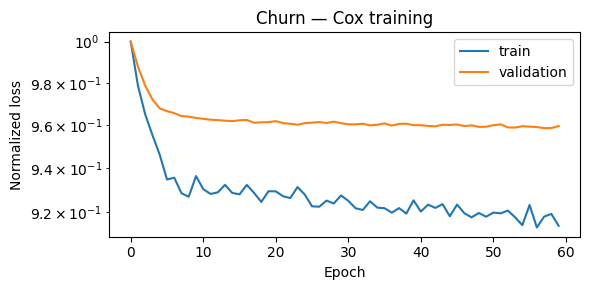

In [6]:
# ── Data loaders ─────────────────────────────────────────────────────────────
loader_train_ch, loader_val_ch, loader_test_ch = make_loaders(X_churn, event_obs, time_obs)

# ── Cox model ────────────────────────────────────────────────────────────────
torch.manual_seed(1)
cox_churn = MLP(in_features=4, out_features=1)

train_losses_ch, val_losses_ch = train(
    cox_churn,
    loader_train_ch,
    loader_val_ch,
    loss_fn=lambda out, e, t: cox.neg_partial_log_likelihood(out, e, t),
)
plot_losses(train_losses_ch, val_losses_ch, title="Churn — Cox training")

In [7]:
results.append(evaluate_cox(cox_churn, loader_test_ch, "Customer Churn"))

 Customer Churn — Cox Model Results
  C-index         : 0.6917
  95% CI          : tensor([0.5998, 0.7835])
  AUC (median t)  : 0.7358


---
## 2. Employee Attrition — HR Analytics

**Scenario**: An HR team wants to model *when* an employee is likely to resign.
The event is **resignation**. The time is **months of tenure**. Employees still at the company
at the snapshot date are **right-censored**.

**Features**: Job satisfaction score, distance from home, overtime flag, salary band, years since last promotion.

> 📂 **Real Dataset**: [IBM HR Analytics Employee Attrition — Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)
> 1,470 employees with 35 features including satisfaction scores, overtime, and attrition indicator.
> *In this notebook we use synthetic data with matching statistical properties to keep the example self-contained and fast to run.*

In [8]:
# ── Synthetic Attrition Data ─────────────────────────────────────────────────
rng = np.random.default_rng(1)
N = 800

satisfaction = rng.uniform(1, 5, N)  # 1=low, 5=high job satisfaction
distance_home = rng.exponential(15, N)  # km from home
overtime = rng.choice([0, 1], N, p=[0.7, 0.3]).astype(float)
salary_band = rng.choice([1, 2, 3, 4], N).astype(float)  # 1=lowest, 4=highest
yrs_since_promo = rng.poisson(2, N).astype(float)

# log_scale scales with time in Weibull AFT, so positive coeff = longer survival (lower resignation risk)
log_scale = (
    0.3 * satisfaction
    - 0.01 * distance_home
    - 0.4 * overtime
    + 0.2 * salary_band
    - 0.1 * yrs_since_promo
    + rng.normal(0, 0.3, N)
)
scale = np.exp(log_scale + 3.0)  # baseline ~20 months
shape = 1.5
attrition_time = scale * rng.weibull(shape, N)
censoring_time = rng.uniform(1, 60, N)
time_obs_att = np.minimum(attrition_time, censoring_time)
event_obs_att = (attrition_time <= censoring_time).astype(bool)

print(f"Resignation rate: {event_obs_att.mean():.1%}  |  Median tenure: {np.median(time_obs_att):.1f} months")

X_att = np.column_stack([satisfaction, distance_home, overtime, salary_band, yrs_since_promo])

Resignation rate: 37.1%  |  Median tenure: 20.5 months


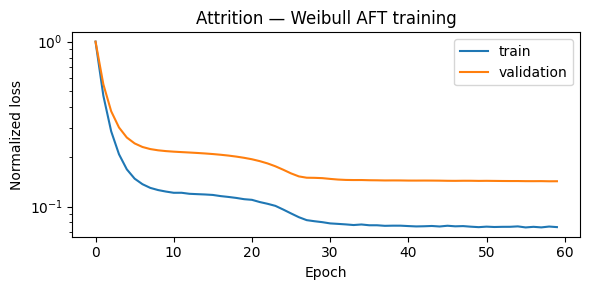

In [9]:
# ── Data loaders ─────────────────────────────────────────────────────────────
loader_train_att, loader_val_att, loader_test_att = make_loaders(X_att, event_obs_att, time_obs_att)

# ── Weibull AFT model ────────────────────────────────────────────────────────
torch.manual_seed(2)
weibull_att = MLP(in_features=5, out_features=2)


def weibull_loss(out, e, t):
    return weibull.neg_log_likelihood_weibull(out, e, t)


train_losses_att, val_losses_att = train(weibull_att, loader_train_att, loader_val_att, loss_fn=weibull_loss)
plot_losses(train_losses_att, val_losses_att, title="Attrition — Weibull AFT training")

In [10]:
results.append(evaluate_weibull(weibull_att, loader_test_att, "Employee Attrition"))

 Employee Attrition — Weibull AFT Model Results
  C-index         : 0.5867
  95% CI          : tensor([0.4423, 0.7311])
  AUC (median t)  : 0.6214


---
## 3. Equipment Failure — Predictive Maintenance

**Scenario**: A manufacturer monitors industrial machines and wants to predict *when* each unit will fail.
The event is **mechanical failure**. The time is **operating hours**. Machines still running
at the end of the monitoring window are **right-censored**.

**Features**: Average load (%), operating temperature (°C), vibration level, machine age (years), maintenance cycles.

> 📂 **Real Dataset**: [NASA CMAPSS Turbofan Engine Degradation Dataset](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/)
> Engine run-to-failure data with multiple sensor readings. Widely used benchmark for RUL prediction.
> *In this notebook we use synthetic data with matching statistical properties to keep the example self-contained and fast to run.*

In [11]:
# ── Synthetic Equipment Failure Data ──────────────────────────────────────────
rng = np.random.default_rng(2)
N = 800

load = rng.uniform(40, 100, N)  # % capacity
temperature = rng.normal(75, 20, N)  # °C operating temperature
vibration = rng.exponential(0.5, N)  # vibration index
age_years = rng.uniform(0, 12, N)  # years in service
maint_cycles = rng.poisson(5, N).astype(float)  # # of maintenance events

log_hz_true = (
    0.01 * load + 0.01 * temperature + 0.5 * vibration + 0.08 * age_years - 0.1 * maint_cycles + rng.normal(0, 0.4, N)
)
baseline_hours = 2000.0
time_failure = rng.exponential(baseline_hours / np.exp(log_hz_true))
censoring_h = rng.uniform(200, 4000, N)
time_obs_eq = np.minimum(time_failure, censoring_h)
event_obs_eq = (time_failure <= censoring_h).astype(bool)

print(f"Failure rate: {event_obs_eq.mean():.1%}  |  Median observed hours: {np.median(time_obs_eq):.0f}")

X_eq = np.column_stack([load, temperature, vibration, age_years, maint_cycles])

Failure rate: 91.4%  |  Median observed hours: 219


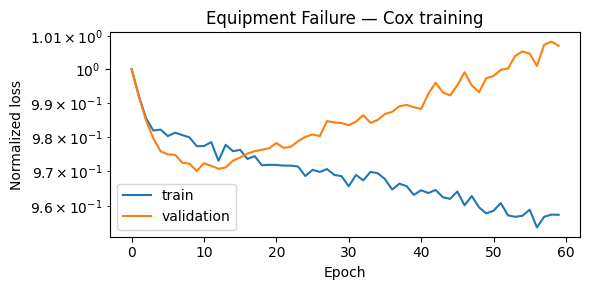

In [12]:
# ── Data loaders ─────────────────────────────────────────────────────────────
loader_train_eq, loader_val_eq, loader_test_eq = make_loaders(X_eq, event_obs_eq, time_obs_eq)

# ── Cox model ────────────────────────────────────────────────────────────────
torch.manual_seed(3)
cox_eq = MLP(in_features=5, out_features=1)

train_losses_eq, val_losses_eq = train(
    cox_eq,
    loader_train_eq,
    loader_val_eq,
    loss_fn=lambda out, e, t: cox.neg_partial_log_likelihood(out, e, t),
)
plot_losses(train_losses_eq, val_losses_eq, title="Equipment Failure — Cox training")

In [13]:
results.append(evaluate_cox(cox_eq, loader_test_eq, "Equipment Failure"))

 Equipment Failure — Cox Model Results
  C-index         : 0.5932
  95% CI          : tensor([0.4863, 0.7002])
  AUC (median t)  : 0.5961


---
## 4. Loan Default — Credit Risk

**Scenario**: A lender wants to model *when* a borrower will default on a loan.
The event is **default**. The time is **months since loan origination**. Loans that
were fully repaid or are still active are **right-censored**.

**Features**: Loan amount (USD), credit score, debt-to-income ratio, employment length (years), loan purpose (encoded).

> 📂 **Real Dataset**: [Give Me Some Credit — Kaggle](https://www.kaggle.com/c/GiveMeSomeCredit)
> 150,000 borrowers with features including revolving utilization, age, and 90-day delinquency history.
> *In this notebook we use synthetic data with matching statistical properties to keep the example self-contained and fast to run.*

In [14]:
# ── Synthetic Loan Default Data ──────────────────────────────────────────────
rng = np.random.default_rng(3)
N = 800

loan_amount = rng.uniform(5000, 50000, N)
credit_score = rng.normal(680, 80, N).clip(300, 850)
dti_ratio = rng.beta(2, 5, N) * 60  # debt-to-income (%)
emp_length = rng.exponential(4, N).clip(0, 20)  # years employed
loan_purpose = rng.choice([0, 1, 2, 3], N).astype(float)  # 0=personal,1=auto,2=home,3=education

log_scale_true = (
    -0.0001 * loan_amount
    + 0.005 * credit_score
    - 0.03 * dti_ratio
    + 0.05 * emp_length
    - 0.1 * loan_purpose
    + rng.normal(0, 0.3, N)
)
scale = np.exp(log_scale_true + 3.5)  # baseline ~33 months
shape = 1.2
time_default = scale * rng.weibull(shape, N)
# Loan term is 36 or 60 months
loan_term = rng.choice([36, 60], N).astype(float)
time_obs_ln = np.minimum(time_default, loan_term)
event_obs_ln = (time_default <= loan_term).astype(bool)

print(f"Default rate: {event_obs_ln.mean():.1%}  |  Median time to default/payoff: {np.median(time_obs_ln):.1f} months")

X_ln = np.column_stack([loan_amount, credit_score, dti_ratio, emp_length, loan_purpose])

Default rate: 60.8%  |  Median time to default/payoff: 27.5 months


In [15]:
# ── Data loaders ─────────────────────────────────────────────────────────────
loader_train_ln, loader_val_ln, loader_test_ln = make_loaders(X_ln, event_obs_ln, time_obs_ln)

# ── Weibull AFT model ────────────────────────────────────────────────────────
torch.manual_seed(4)
weibull_ln = MLP(in_features=5, out_features=2)

train_losses_ln, val_losses_ln = train(weibull_ln, loader_train_ln, loader_val_ln, loss_fn=weibull_loss)
plot_losses(train_losses_ln, val_losses_ln, title="Loan Default — Weibull AFT training")

In [16]:
results.append(evaluate_weibull(weibull_ln, loader_test_ln, "Loan Default"))

 Loan Default — Weibull AFT Model Results
  C-index         : 0.7817
  95% CI          : tensor([0.6919, 0.8715])
  AUC (median t)  : 0.8634


---
## 5. Extreme Weather Events — Meteorology

**Scenario**: A meteorologist wants to model *when* a weather station will next record an extreme
temperature event (>95th percentile). The event is **threshold exceedance**. The time is **days
between consecutive extreme events** at a station. Stations still under observation (no event yet)
are **right-censored**.

**Features**: Average summer temperature anomaly (°C), elevation (m), coastal proximity (0/1),
mean annual rainfall (mm), latitude zone (encoded).

> 📂 **Real Dataset**: [NOAA Storm Events Database](https://www.ncdc.noaa.gov/stormevents/)
> Detailed records of storm events across the US with start/end dates, location, and severity — suitable for time-to-event modeling of extreme weather.
> *In this notebook we use synthetic data with matching statistical properties to keep the example self-contained and fast to run.*

In [17]:
# ── Synthetic Extreme Weather Data ───────────────────────────────────────────
rng = np.random.default_rng(4)
N = 800

temp_anomaly = rng.normal(0.8, 0.5, N)  # °C above historical mean
elevation = rng.exponential(300, N)  # meters
coastal = rng.choice([0, 1], N, p=[0.6, 0.4]).astype(float)
rainfall_mm = rng.normal(600, 200, N).clip(50)  # mm/year
latitude_zone = rng.choice([0, 1, 2], N).astype(float)  # 0=tropical,1=temperate,2=polar

log_hz_true = (
    0.4 * temp_anomaly
    - 0.001 * elevation
    - 0.2 * coastal  # coastal areas more buffered
    - 0.0005 * rainfall_mm
    + 0.1 * latitude_zone
    + rng.normal(0, 0.3, N)
)
baseline_days = 120.0
time_weather = rng.exponential(baseline_days / np.exp(log_hz_true))
obs_window = rng.uniform(30, 365, N)
time_obs_wt = np.minimum(time_weather, obs_window)
event_obs_wt = (time_weather <= obs_window).astype(bool)

print(f"Event rate: {event_obs_wt.mean():.1%}  |  Median inter-event gap: {np.median(time_obs_wt):.0f} days")

X_wt = np.column_stack([temp_anomaly, elevation, coastal, rainfall_mm, latitude_zone])

Event rate: 68.2%  |  Median inter-event gap: 73 days


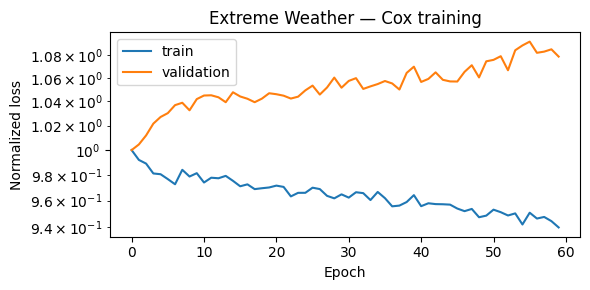

In [18]:
# ── Data loaders ─────────────────────────────────────────────────────────────
loader_train_wt, loader_val_wt, loader_test_wt = make_loaders(X_wt, event_obs_wt, time_obs_wt, batch_size=32)

# ── Cox model ────────────────────────────────────────────────────────────────
torch.manual_seed(5)
cox_wt = MLP(in_features=5, out_features=1)

train_losses_wt, val_losses_wt = train(
    cox_wt,
    loader_train_wt,
    loader_val_wt,
    loss_fn=lambda out, e, t: cox.neg_partial_log_likelihood(out, e, t),
)
plot_losses(train_losses_wt, val_losses_wt, title="Extreme Weather — Cox training")

In [19]:
results.append(evaluate_cox(cox_wt, loader_test_wt, "Extreme Weather"))

 Extreme Weather — Cox Model Results
  C-index         : 0.6317
  95% CI          : tensor([0.5160, 0.7475])
  AUC (median t)  : 0.6831


---
## 6. Cross-Domain Comparison

Below we summarize the C-index and AUC (at median event time) across all five domains.

A C-index of **0.5** is equivalent to random guessing; **1.0** is perfect discrimination.
The same interpretation holds for AUC.

In [20]:
import pandas as pd

summary = pd.DataFrame(results)
summary = summary.set_index("domain")
summary.columns = ["Model", "C-index", "AUC (median t)"]
summary["C-index"] = summary["C-index"].map("{:.4f}".format)
summary["AUC (median t)"] = summary["AUC (median t)"].map("{:.4f}".format)
print(summary.to_string())

                          Model C-index AUC (median t)
domain                                                
Customer Churn              Cox  0.6917         0.7358
Employee Attrition  Weibull AFT  0.5867         0.6214
Equipment Failure           Cox  0.5932         0.5961
Loan Default        Weibull AFT  0.7817         0.8634
Extreme Weather             Cox  0.6317         0.6831


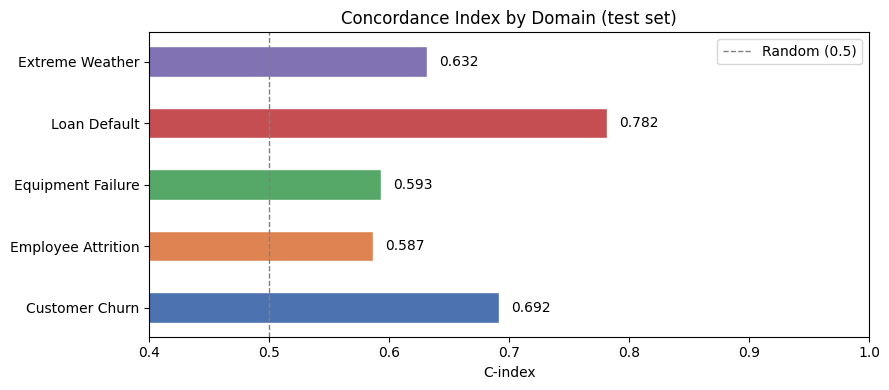

In [ ]:
# Visual comparison
fig, ax = plt.subplots(figsize=(9, 4))
domains = [r["domain"] for r in results]
cindexes = [r["cindex"] for r in results]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

bars = ax.barh(domains, cindexes, color=colors, edgecolor="white", height=0.5)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Random (0.5)")
ax.set_xlim(0.4, 1)
ax.set_xlabel("C-index")
ax.set_title("Concordance Index by Domain (test set)")
ax.legend()
for bar, val in zip(bars, cindexes):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated that `TorchSurv` applies cleanly to **any time-to-event problem**:

- **Same API** regardless of domain — swap in your data and your architecture
- **Cox model**: great when the proportional hazards assumption holds; outputs a risk ranking
- **Weibull AFT model**: directly models survival time; outputs interpretable scale/shape parameters
- **Censoring is handled automatically** — no need to drop or impute incomplete observations

### Next steps
- Replace synthetic data with the linked real datasets for each domain
- Try deeper architectures or domain-specific features
- Use `cindex.compare(other_cindex)` to test whether one model significantly outperforms another
- See the [TorchSurv documentation](https://opensource.nibr.com/torchsurv/) for time-varying covariates, momentum training, and more